# End to End forcasting pipeline

Predictive Modeling:

Accurate electricity demand forecasting is essential for anticipating future energy requirements, estimating carbon emissions, and supporting operational planning. To maintain high accuracy in dynamic energy markets, the platform employs a robust online and incremental learning framework alongside its core multi-model architecture, allowing models to continuously adapt to evolving demand patterns and concept drift without requiring full retraining from scratch.

Adaptive AI Models: The platform uses a blend of specialized neural networks (LSTM and TFT) alongside Google's advanced time-series AI (TimesFM) using transfer learning. These models learn long-term patterns while continuously tweaking their internal weights using incoming streaming data to handle sudden load shifts and concept drift.
Smart Uncertainty Ranges (Probabilistic Forecasts): Rather than guessing a single fixed number, the models provide a range of outcomes—specifically P10, P50, and P90 estimates. This means it calculates conservative, expected, and peak demand scenarios so decision-makers can plan for best- and worst-case situations safely.
Auto-Correcting Accuracy: The platform uses automated safety checks (conformal calibration) to continuously monitor its own error rates. If forecasts start drifting off target, the system self-corrects its uncertainty ranges and seamlessly falls back to a reliable backup baseline model if any anomaly occurs.
Model Optimization & Efficiency: To ensure low-latency performance and a lightweight resource footprint, the platform applies **structured pruning** to remove redundant internal layers and connections from deep architectures. It then uses **fine-tuning** workflows to recover any predictive accuracy lost during the pruning phase prior to live production deployment.


Carbon Insights:
Forecasting electricity demand alone does not indicate the environmental impact of meeting that demand. The platform therefore combines demand forecasts with carbon intensity and renewable energy data obtained from external providers. This enables users to estimate future carbon emissions alongside future electricity demand, supporting sustainability reporting and operational decision-making.
Where renewable energy metrics are unavailable, the platform derives the renewable proportion from the observed electricity generation mix, ensuring carbon insights remain available even when external data is incomplete

Model Lifecycle Management:
Machine learning models continuously evolve as new data becomes available and forecasting performance improves. The platform uses MLflow to manage the complete model lifecycle, including experiment tracking, model versioning, artifact storage, validation, and deployment.
Although these tasks could be managed manually, MLflow provides a standardized and reproducible workflow. It records training parameters, evaluation metrics, datasets, and model artifacts for every experiment, making it easy to compare model versions, reproduce previous results, and safely promote validated models into production. This improves collaboration, simplifies model governance, and ensures consistent production inference.


---

## Tutorial roadmap

This notebook walks through the real code behind every capability described above, one
inspectable step per cell, using the actual `app.service.ml`/`app.models`/
`app.service.mlops` modules `services/forecast-api` trains and serves with -- nothing
here is a simplified standalone reimplementation.

**V2 note**: identical to `forcast_pipeline.ipynb` through Step 13 -- Step 14 is
rewritten to export **ONNX** instead of the `.pt` `state_dict` bundle (see that step's
own markdown for why, and its current real-vs-aspirational status).

| # | Section | What it demonstrates |
|---|---|---|
| 0 | Setup | Import the real pipeline modules |
| 1 | Configuration | The knobs you'll actually touch |
| 2 | Load data from DuckDB | The data source this whole notebook runs on |
| 3 | Look before you train | Missingness + a sanity plot |
| 4 | Feature engineering | Lags, rolling stats, calendar features |
| 5-6 | Train `DemandLSTM` | Chronological split, per-region scaling, quantile heads, **conformal calibration**, **bias correction** |
| 7 | Inspect the trained model | Loss curves, real calibrated coverage |
| 8 | Baseline fallback | The trained model vs. the "always available" seasonal-naive floor |
| 9 | Visualize a forecast | P10-P90 band vs. actual, via the real serving-path `LSTMForecaster` |
| 10 | Structured pruning | Real size/latency reduction, measured |
| 11 | Carbon insights | Real NGER emission factors + real generation mix -> emissions & intensity |
| 12 | Beyond LSTM: TFT & TimesFM | Zero-shot TimesFM alongside the trained LSTM, and where TFT/continuous adaptation fit |
| 13 | MLflow lifecycle | Registration, and how promotion is gated |
| 14 | Export to ONNX | Framework-agnostic export, self-verified against the original PyTorch model, packaged for `POST /v1/model/versions/import-onnx` -- not yet built, see that step's own note |

**Prerequisites:** run this notebook with `services/forecast-api/.venv`'s Python as the
Jupyter kernel -- it already has `duckdb`, `torch`, `onnx`/`onnxruntime`, `mlflow`, and
everything else this pipeline needs. No GPU required.


## Step 0 -- Setup

In [1]:
import sys
from pathlib import Path

_SERVICE_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_SERVICE_ROOT) not in sys.path:
    sys.path.insert(0, str(_SERVICE_ROOT))

import sys as _sys
print(f"Python: {_sys.executable}")
assert ".venv" in _sys.executable, (
    "This notebook expects the forecast-api .venv kernel -- "
    "select services/forecast-api/.venv/bin/python as the Jupyter kernel."
)

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# This host has 8 CPU cores and 8GB RAM total, running Docker Desktop's own VM
# (5.8GB cap, 16 containers -- including `train-worker`, which auto-trains on
# new data independently of this notebook) alongside everything else. Real,
# confirmed-live 2026-08-20: torch's default thread count (4, one per
# performance core) saturating CPU during Steps 5/10/12 measurably starves the
# Docker Desktop VM's own responsiveness -- including MLflow's -- for a real
# stretch of wall-clock time afterward (reproduced directly: `configure_mlflow`
# call fails immediately post-training, succeeds again after a real cooldown).
# Capping threads trades some training wall-clock time for leaving the rest of
# the host usable, which Step 13 below depends on.
torch.set_num_threads(2)

from app.core.config import get_settings
from app.models.baseline import seasonal_naive_forecast  # noqa: F401 -- imported for reference, wrapped by BaselineForecaster below
from app.service.ml.carbon_engine import CarbonEngine
from app.service.ml.demand_data_offline import (
    load_demand_training_data_from_master,
    load_holidays_from_master,
)
from app.service.ml.emission_factors import GENERATION_BUCKET_FUEL_TYPES, compute_bucket_factors
from app.service.ml.energy_data_offline import REGIONS_ALL, ensure_master_table
from app.service.ml.evaluate import (
    BaselineForecaster,
    LSTMForecaster,
    _infer_period_steps,
    evaluate_walk_forward,
)
from app.service.ml.features import FEATURE_COLUMNS, TARGET_COLUMN, build_features
from app.service.ml.prune import benchmark_models, compact_lstm
from app.service.ml.train import TrainConfig, log_and_register_run, train_model
from app.service.mlops.registry import get_version_in_stage
from app.service.mlops.tracking import configure_mlflow, git_sha
from app.models.timesfm_adapter import load_timesfm_forecaster

%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 4)
print("Imports OK.")


Python: /Users/macbook/Project/research/EcoLens/services/forecast-api/.venv/bin/python
Imports OK.


## Step 1 -- Configuration

`TrainConfig.from_settings(...)` reads the same production defaults `ecolens-forecast
train` (the CLI) does -- 50 epochs, `lookback=24`, `horizon=48`. This tutorial dials
epochs down for a fast first pass; bump it back up for a real run.


In [2]:
settings = get_settings()

# Start narrow for a fast first pass -- widen to list(REGIONS_ALL) for a real run.
REGIONS = ["NSW1", "VIC1"]
SINCE: pd.Timestamp | None = None
MODEL_NAME = settings.mlflow_registry_model_name
REGISTER_MODEL = False  # flip to True in Step 13 once you trust the run

config = TrainConfig.from_settings(settings)
config.epochs = 10  # production default is 50
config


TrainConfig(lookback=24, horizon=48, hidden_size=128, num_layers=2, dropout=0.25, weight_decay=1e-05, lr=0.001, epochs=10, batch_size=64, quantile_weight=1.0, conformal_alpha=0.2, cal_frac=0.5, early_stopping_patience=5, train_frac=0.49, val_frac=0.49, train_start=None, train_end=None, val_start=None, val_end=None, test_start=None, test_end=None, shuffle=True)

## Step 2 -- Load data from DuckDB

Same reasoning as the multi-task pipeline's own DuckDB path: `master.duckdb` is a
single self-contained file built from real landed AEMO/OpenElectricity/BoM data, no
server or live-warehouse dbt build required. `load_demand_training_data_from_master`
resamples it to hourly (matching `DemandLSTM`'s `lookback`/`horizon` contract, which is
defined in hours) and returns the exact shape `ml/train.py`'s live-warehouse loader
would.


In [3]:
db_path = ensure_master_table()
print(f"master.duckdb: {db_path}")

with duckdb.connect(str(db_path), read_only=True) as conn:
    coverage = conn.execute(
        """
        SELECT region, count(*) AS n_rows, min(bucket_ts) AS min_ts, max(bucket_ts) AS max_ts
        FROM master GROUP BY region ORDER BY region
        """
    ).df()
coverage


master.duckdb: /Users/macbook/Project/research/EcoLens/services/ingestion/data/training/master.duckdb


,region,n_rows,min_ts,max_ts
0,NSW1,35062,2024-08-12 20:00:00+06:00,2026-08-13 13:30:00+06:00
1,QLD1,35062,2024-08-12 20:00:00+06:00,2026-08-13 13:30:00+06:00
2,SA1,35062,2024-08-12 20:00:00+06:00,2026-08-13 13:30:00+06:00
3,TAS1,35062,2024-08-12 20:00:00+06:00,2026-08-13 13:30:00+06:00
4,VIC1,35062,2024-08-12 20:00:00+06:00,2026-08-13 13:30:00+06:00
5,WEM,35062,2024-08-12 20:00:00+06:00,2026-08-13 13:30:00+06:00


In [4]:
raw_df = load_demand_training_data_from_master(REGIONS, since=SINCE)
holidays_df = load_holidays_from_master()

print(f"raw_df: {raw_df.shape}, regions={sorted(raw_df['region'].unique())}")
raw_df.head()


raw_df: (35076, 10), regions=['NSW1', 'VIC1']


,region,ts,demand_mw,price_mwh,total_generation_mw,total_renewable_mw,temp_c,apparent_temp_c,humidity_pct,wind_speed_kmh
0,NSW1,2024-08-12 14:00:00+00:00,7824.939167,89.997074,NaN,NaN,18.2,17.5,73.0,11.3
1,NSW1,2024-08-12 15:00:00+00:00,7412.290833,98.106587,NaN,NaN,18.2,17.5,73.0,11.3
2,NSW1,2024-08-12 16:00:00+00:00,7024.961667,103.987776,NaN,NaN,18.2,17.5,73.0,11.3
3,NSW1,2024-08-12 17:00:00+00:00,6772.305833,102.666906,NaN,NaN,18.2,17.5,73.0,11.3
4,NSW1,2024-08-12 18:00:00+00:00,6864.329167,96.384734,NaN,NaN,18.2,17.5,73.0,11.3


## Step 3 -- Look before you train

In [5]:
raw_df.drop(columns=["ts", "region"]).isna().mean().sort_values(ascending=False)


total_generation_mw    0.010263
total_renewable_mw     0.010263
demand_mw              0.006956
price_mwh              0.006956
temp_c                 0.000342
apparent_temp_c        0.000342
humidity_pct           0.000342
wind_speed_kmh         0.000342
dtype: float64

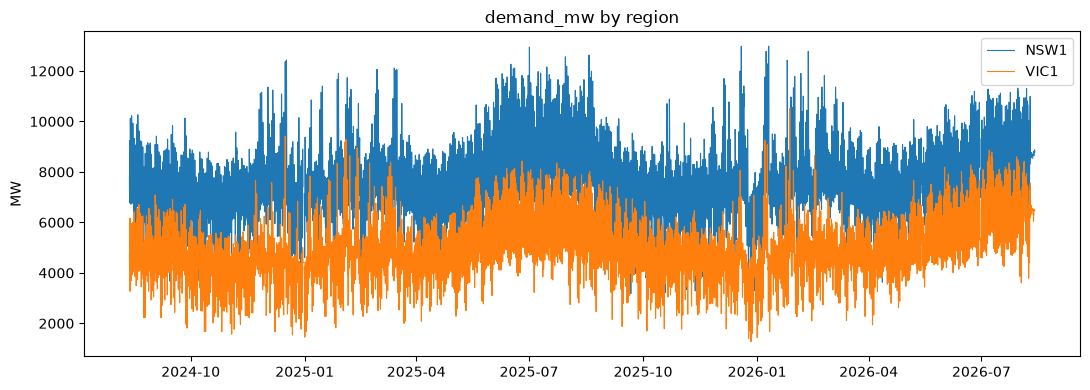

In [6]:
fig, ax = plt.subplots()
for region, group in raw_df.groupby("region"):
    ax.plot(group["ts"], group[TARGET_COLUMN], label=region, linewidth=0.8)
ax.set_title(f"{TARGET_COLUMN} by region")
ax.set_ylabel("MW")
ax.legend()
fig.tight_layout()


## Step 4 -- Feature engineering

`build_features` (`app/service/ml/features.py`) adds the lag/rolling/calendar columns
`FEATURE_COLUMNS` lists -- the same feature set the live-warehouse training path builds,
just run here against DuckDB-sourced rows instead.


In [7]:
engineered = build_features(raw_df, holidays=holidays_df)
print(f"engineered: {engineered.shape}  ({len(FEATURE_COLUMNS)} feature columns)")
engineered[list(FEATURE_COLUMNS)].isna().mean().sort_values(ascending=False).head(8)


engineered: (35076, 43)  (37 feature columns)


total_generation_mw    0.010263
total_renewable_mw     0.010263
demand_mw_lag_12       0.007241
price_mwh              0.006956
demand_mw_lag_6        0.006956
demand_mw_lag_3        0.006956
demand_mw_lag_2        0.006956
demand_mw_lag_1        0.006956
dtype: float64

## Step 5 -- What `train_model` does, before you run it

`train_model` (`app/service/ml/train.py`) is the real, tested training entrypoint --
the same function `ecolens-forecast train` calls. Rather than re-deriving its ~400 lines
by hand (real risk of silently diverging from what production actually does), this
tutorial calls it directly and spends this cell on what it does internally, so the next
cell's output is legible:

1. **Per-region chronological split.** Not one global split boundary -- each region gets
   its own train/val/calibration/test cut against its *own* timestamps, then the splits
   are combined. A single shared boundary would let whichever region has the longest
   history dominate where the cut falls, starving a shorter-history region of its own
   fair share of train/val data.
2. **Per-region scaling**, features and target alike -- NSW1's demand (~8,700 MW) and
   TAS1's (~1,100 MW) aren't the same scale; one shared scaler would let the larger
   region dominate and leave the smaller one under-precision.
3. **A held-out calibration split, disjoint from early-stopping's validation split.**
   `DemandLSTM`'s P10/P90 heads are trained with pinball loss, but pinball loss alone has
   no *guaranteed* coverage -- it tends to under-cover in practice. `cal_frac` carves out
   a slice of validation data early stopping never looks at, specifically for **conformal
   calibration** (Step 7 shows the real effect).
4. **Per-region bias correction**, computed on that same calibration split -- the real
   mean `(actual - p50)` offset per region, applied to P10/P90 before conformal widening.
5. **Early stopping on validation MAPE**, restoring the *best* epoch's weights, not the
   last one.


In [8]:
result = train_model(raw_df, config, holidays=holidays_df)
print(f"windows -- train: {result.n_train_windows}  val: {result.n_val_windows}  "
      f"cal: {result.n_cal_windows}  test: {result.n_test_windows}")


{"counts": {"NSW1": [8300, 4250, 3897], "VIC1": [8300, 4250, 3897]}, "event": "train_model.region_window_counts", "service": "forecast-api", "environment": "development", "version": "0.1.0", "level": "info", "timestamp": "2026-08-21T17:14:02.419951Z"}
{"epoch": 0, "train_loss": 0.5272430350001042, "val_loss": 0.5067772208748007, "val_mape": 14.018778800964355, "val_rmse": 948.8851928710938, "val_mae": 687.84375, "event": "train.epoch", "service": "forecast-api", "environment": "development", "version": "0.1.0", "level": "info", "timestamp": "2026-08-21T17:14:09.671446Z"}
{"epoch": 1, "train_loss": 0.34557669449311035, "val_loss": 0.4635206104669356, "val_mape": 12.142285346984863, "val_rmse": 884.6499633789062, "val_mae": 623.824951171875, "event": "train.epoch", "service": "forecast-api", "environment": "development", "version": "0.1.0", "level": "info", "timestamp": "2026-08-21T17:14:15.351390Z"}
{"epoch": 2, "train_loss": 0.30565361529588697, "val_loss": 0.4522703797521448, "val_map

## Step 6 -- Read the training history back

`result.history` has one entry per epoch: `train_loss` (scaled-space pinball+Huber),
`val_loss` (the same loss, on validation data), and `val_mape`/`val_rmse`/`val_mae`
(real MW-space metrics on validation P50 -- what early stopping actually watched).


test metrics: {'test_mape': 7.646477222442627, 'test_coverage_raw': 0.6651785714285714, 'test_coverage_calibrated': 0.8584656084656085, 'test_interval_width_raw_mw': 1197.015380859375, 'test_interval_width_calibrated_mw': 1806.53402552529}


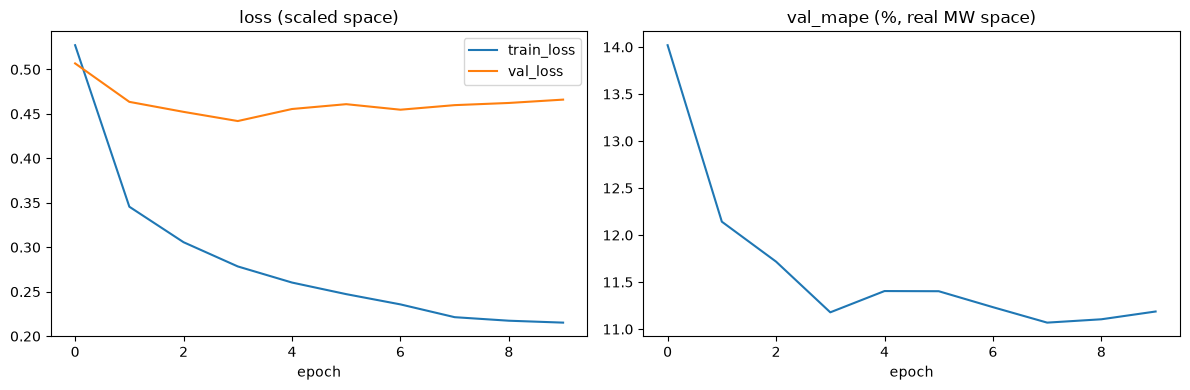

In [9]:
epochs = [h["epoch"] for h in result.history]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs, [h["train_loss"] for h in result.history], label="train_loss")
ax1.plot(epochs, [h["val_loss"] for h in result.history], label="val_loss")
ax1.set_title("loss (scaled space)")
ax1.set_xlabel("epoch")
ax1.legend()

ax2.plot(epochs, [h["val_mape"] for h in result.history])
ax2.set_title("val_mape (%, real MW space)")
ax2.set_xlabel("epoch")
fig.tight_layout()
print(f"test metrics: {result.test_metrics}")


## Step 7 -- Did conformal calibration actually help?

`result.test_metrics['test_coverage_raw']` is how often the true value fell inside the
model's *raw* P10-P90 band on the test split; `test_coverage_calibrated` is the same
check after applying `result.calibration` (fit on the disjoint calibration split from
Step 5). The target is 80% (`conformal_alpha=0.2`). If raw coverage undershoots 80% and
calibrated coverage lands closer to it, that's conformal calibration doing its real job
-- not a cosmetic step.

`result.bias_correction.bias_by_region` is each region's own learned P50 offset -- a
non-zero value here is a real, systematic bias conformal calibration's *symmetric*
widening wouldn't fix on its own (it widens the interval; it doesn't re-center it).


In [10]:
print("Conformal calibration q (per horizon step, MW):", result.calibration.q[:5], "...")
print()
print(f"raw test coverage:        {result.test_metrics.get('test_coverage_raw', float('nan')):.1%}  (target: 80%)")
print(f"calibrated test coverage: {result.test_metrics.get('test_coverage_calibrated', float('nan')):.1%}  (target: 80%)")
print()
print("per-region P50 bias (MW, mean actual - predicted on the calibration split):")
for region, bias in result.bias_correction.bias_by_region.items():
    print(f"  {region}: mean={bias.mean():+.1f} MW")


Conformal calibration q (per horizon step, MW): [179.42675781 211.57226562 224.22045898 225.84570312 236.71972656] ...

raw test coverage:        66.5%  (target: 80%)
calibrated test coverage: 85.8%  (target: 80%)

per-region P50 bias (MW, mean actual - predicted on the calibration split):
  NSW1: mean=-171.6 MW
  VIC1: mean=+176.3 MW


## Step 8 -- The baseline fallback

The platform's "reliable backup" isn't another neural net -- it's `BaselineForecaster`,
a seasonal-naive model (`app/models/baseline.py`): "demand at this time is whatever it
was one real seasonal period ago." Cheap, always available, no training, no failure
mode more complex than "not enough history yet." Every trained architecture is measured
against it, not just against its own validation curve -- a model that can't beat this
floor isn't earning its complexity.

`evaluate_walk_forward` runs both forecasters through the same real rolling-origin
backtest (`n_origins` evenly-spaced forecast origins per region, scored against what
actually happened) -- the harness this tutorial's `LSTMForecaster` and TimesFM (Step 12)
both plug into identically.


In [11]:
lstm_forecaster = LSTMForecaster(
    model=result.model,
    feature_scalers=result.feature_scalers,
    target_scaler=result.target_scaler,
    lookback=config.lookback,
    calibration=result.calibration,
    bias_correction=result.bias_correction,
    name="lstm_demand",
)

comparison_rows = []
for region in REGIONS:
    region_df = engineered[engineered["region"] == region].sort_values("ts").reset_index(drop=True)
    if region_df.empty:
        continue

    lstm_report = evaluate_walk_forward(
        lstm_forecaster, region_df, config.horizon, n_origins=10, min_history=config.lookback
    )
    comparison_rows.append({"region": region, "model": lstm_forecaster.name, **lstm_report.as_mlflow_metrics()})

    try:
        period_steps = _infer_period_steps(region_df)
    except ValueError:
        continue
    baseline_forecaster = BaselineForecaster(period_steps=period_steps)
    baseline_report = evaluate_walk_forward(
        baseline_forecaster, region_df, config.horizon, n_origins=10, min_history=period_steps + 1
    )
    comparison_rows.append({"region": region, "model": baseline_forecaster.name, **baseline_report.as_mlflow_metrics()})

comparison = pd.DataFrame(comparison_rows)
# `EvaluationReport.as_mlflow_metrics()` (`app/service/ml/evaluate.py`) keys
# every metric `eval_*` (e.g. `eval_mape`, not `mape`) -- that's the real,
# intentional name MLflow logs the metric under, so this selects the same
# prefixed names rather than the report dataclass's own bare field names.
comparison[["region", "model", "eval_mape", "eval_rmse", "eval_coverage"]]


,region,model,eval_mape,eval_rmse,eval_coverage
0,NSW1,lstm_demand,5.287014,525.894232,0.927083
1,NSW1,seasonal_naive,6.253944,631.095993,0.583333
2,VIC1,lstm_demand,7.866592,463.535910,0.895833
3,VIC1,seasonal_naive,8.858102,524.855063,0.619792


## Step 9 -- Visualize one forecast

This calls `LSTMForecaster.predict` directly -- the exact same method the real serving
path (`/v1/forecast`) calls, already wired with calibration and bias correction, not a
hand-rolled re-implementation of inference.


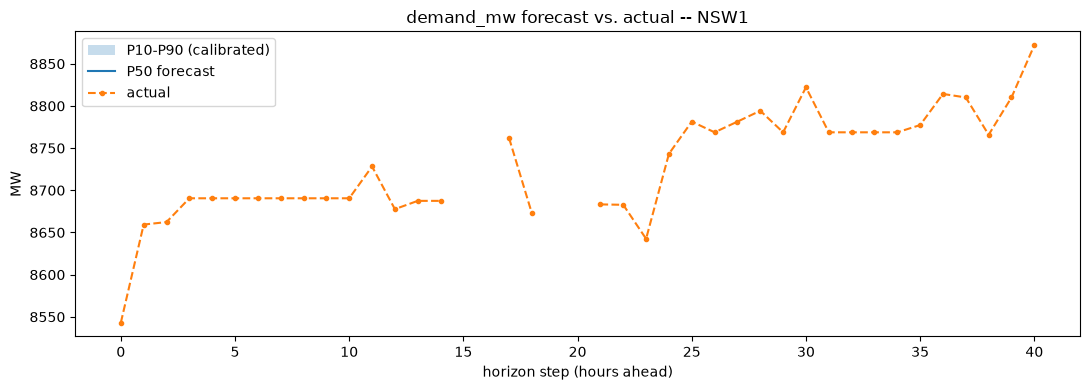

In [12]:
sample_region = REGIONS[0]
region_df = engineered[engineered["region"] == sample_region].sort_values("ts").reset_index(drop=True)
origin_idx = len(region_df) - config.horizon - 1  # last real origin with a real future to score against

history = region_df.iloc[: origin_idx + 1]
actual = region_df[TARGET_COLUMN].iloc[origin_idx + 1 : origin_idx + 1 + config.horizon].to_numpy()

p10, p50, p90 = lstm_forecaster.predict(history, config.horizon)

fig, ax = plt.subplots()
steps = np.arange(config.horizon)
ax.fill_between(steps, p10, p90, alpha=0.25, label="P10-P90 (calibrated)")
ax.plot(steps, p50, label="P50 forecast")
ax.plot(steps, actual, label="actual", linestyle="--", marker="o", markersize=3)
ax.set_title(f"{TARGET_COLUMN} forecast vs. actual -- {sample_region}")
ax.set_xlabel("horizon step (hours ahead)")
ax.set_ylabel("MW")
ax.legend()
fig.tight_layout()


## Step 10 -- Structured pruning

`compact_lstm` (`app/service/ml/prune.py`) builds a genuinely smaller `DemandLSTM` --
not a zero-mask, a real shape change -- keeping only the LSTM's most important hidden
units (ranked by `weight_hh_l0` row norm) and copying their actual weights across every
affected tensor. `benchmark_models` then measures the real before/after: parameter
count, on-disk artifact size, and CPU inference latency.

In production, a pruned model this cheap to produce still needs a **recovery fine-tune**
(`prune_and_recover`) before it's trusted -- pruning trades some accuracy for size, and
that accuracy has to be measured and clawed back, not assumed. This cell shows the real
size/latency win; it doesn't run the recovery fine-tune (a second training loop) to keep
this tutorial's runtime bounded -- `app/service/ml/prune.py`'s `prune_and_recover` is
that real next step.


In [13]:
pruned_model, keep_idx = compact_lstm(result.model, keep_fraction=0.5)
benchmark = benchmark_models(result.model, pruned_model, config.lookback)

print(f"hidden_size: {result.model.lstm.hidden_size} -> {pruned_model.lstm.hidden_size}")
print(f"parameters:  {benchmark.original_param_count:,} -> {benchmark.pruned_param_count:,}  "
      f"({benchmark.param_reduction_pct:.1f}% fewer)")
print(f"artifact size: {benchmark.original_artifact_bytes:,} -> {benchmark.pruned_artifact_bytes:,} bytes  "
      f"({benchmark.size_reduction_pct:.1f}% smaller)")
print(f"CPU latency: {benchmark.original_latency_ms:.3f}ms -> {benchmark.pruned_latency_ms:.3f}ms  "
      f"({benchmark.latency_change_pct:+.1f}%, negative = faster)")
print(f"achieves a real win (>=5% smaller, <=10% slower)? {benchmark.achieves_a_real_win()}")


hidden_size: 128 -> 64
parameters:  236,305 -> 69,073  (70.8% fewer)
artifact size: 950,087 -> 281,159 bytes  (70.4% smaller)
CPU latency: 1.081ms -> 0.821ms  (-24.1%, negative = faster)
achieves a real win (>=5% smaller, <=10% slower)? True


## Step 11 -- Carbon insights

Demand alone doesn't say anything about emissions -- that depends on *what's generating*
to meet it. This section reproduces the real `CarbonEngine` (`app/service/ml/
carbon_engine.py`) arithmetic end to end, using DuckDB the same way the rest of this
notebook does: no live warehouse query needed for either half of the calculation.

**Emission factors:** `app/service/ml/emission_factors.py`'s real per-fuel factors come
from `services/waerehouse/dbt/ecolens/seeds/emissions_factors.csv` (DCCEEW National
Greenhouse Accounts Factors, NGER 2025-Q4) via a live Postgres seed table. This notebook
reads the same real, versioned numbers directly from that CSV's values -- a legitimate
simplification for a DuckDB-only tutorial (they're static reference data, not something
that changes per-request), not a different set of numbers.

**Generation-mix weights:** real historical per-fuel generation, summed straight out of
`master.duckdb`'s own `oe_{fuel}_mw` columns -- this *is* "deriving the renewable
proportion from the observed generation mix" the intro above describes, computed for
real instead of asserted.

**Bucketing:** `compute_bucket_factors` (the same pure, DB-free function
`emission_factors.load_generation_bucket_factors` calls after its own live query) blends
each of the 5 buckets' member fuel types by real generation-weighted average -- e.g.
`other`'s blend is dominated by near-zero-emission hydro, not naively averaged with
high-emission but rarely-dispatched distillate.


In [14]:
# The real NGER-2025-Q4 factors this pipeline trains against
# (services/waerehouse/dbt/ecolens/seeds/emissions_factors.csv), read directly rather
# than via a live Postgres seed table -- same real numbers, DuckDB-only path.
INTENSITY_BY_FUEL_TYPE_KGCO2E_PER_MWH = {
    "coal": 910.0,
    "gas": 490.0,
    "diesel": 770.0,
    "distillate": 770.0,
    "hydro": 5.0,
    "wind": 4.0,
    "solar_utility": 5.0,
    "solar_rooftop": 5.0,
    "biomass": 0.0,
    "battery": 0.0,
    "battery_discharge": 0.0,
    "battery_charge": 0.0,
    "pumped_hydro": 0.0,
    "net_import": 0.0,
}

carbon_region = REGIONS[0]
fuel_cols = sorted({ft for members in GENERATION_BUCKET_FUEL_TYPES.values() for ft in members})
select_cols = ", ".join(f"avg(oe_{ft}_mw) AS {ft}" for ft in fuel_cols)

with duckdb.connect(str(db_path), read_only=True) as conn:
    mix_row = conn.execute(
        f"""
        SELECT region, {select_cols}, avg(aemo_demand_mw) AS demand_mw
        FROM master
        WHERE region = ? AND bucket_ts >= (SELECT max(bucket_ts) FROM master WHERE region = ?) - INTERVAL 7 DAY
        GROUP BY region
        """,
        [carbon_region, carbon_region],
    ).df().iloc[0]

generation_mw_by_fuel_type = {ft: max(float(mix_row[ft]), 0.0) for ft in fuel_cols}
bucket_factors = compute_bucket_factors(INTENSITY_BY_FUEL_TYPE_KGCO2E_PER_MWH, generation_mw_by_fuel_type)
print(f"real generation-weighted bucket factors for {carbon_region} (kgCO2e/MWh == gCO2e/kWh):")
bucket_factors


real generation-weighted bucket factors for NSW1 (kgCO2e/MWh == gCO2e/kWh):


{'coal': 910.0000000000001,
 'gas': 490.0,
 'wind': 4.0,
 'solar': 5.000000000000001,
 'other': 2.795255393739147}

In [15]:
# Bucket the same real 7-day-average generation mix into CarbonEngine's 5 sources, and
# feed it through the real engine alongside real average demand for the same window.
bucket_generation_mw = {
    bucket: sum(generation_mw_by_fuel_type[ft] for ft in members)
    for bucket, members in GENERATION_BUCKET_FUEL_TYPES.items()
}

engine = CarbonEngine(emission_factors=bucket_factors, interval_hours=1.0)  # hourly-resampled data

# CarbonEngine.calculate expects generation_mw: (B, H, S, Q), demand_mw: (B, H, Q) --
# one batch, one representative hour, 5 sources, 1 "quantile" (a point estimate here).
source_order = list(bucket_factors.keys())
generation_tensor = torch.tensor(
    [[[[bucket_generation_mw[s]] for s in source_order]]], dtype=torch.float32
)
demand_tensor = torch.tensor([[[float(mix_row["demand_mw"])]]], dtype=torch.float32)

carbon_out = engine.calculate(generation_tensor, demand_tensor)
print(f"region: {carbon_region}  (7-day real average mix)")
print(f"demand: {float(mix_row['demand_mw']):.0f} MW")
for source in source_order:
    print(f"  {source:6s}: {bucket_generation_mw[source]:8.1f} MW  x  {bucket_factors[source]:6.1f} gCO2e/kWh")
print(f"emissions:        {carbon_out['emissions_kg'].item():,.1f} kgCO2e/hour")
print(f"carbon intensity: {carbon_out['carbon_intensity'].item():.1f} gCO2e/kWh")

renewable_buckets = {"wind", "solar"}
renewable_share = sum(bucket_generation_mw[b] for b in renewable_buckets) / sum(bucket_generation_mw.values())
print(f"renewable share (wind+solar / total, derived from the observed mix): {renewable_share:.1%}")


region: NSW1  (7-day real average mix)
demand: 8695 MW
  coal  :   5530.4 MW  x   910.0 gCO2e/kWh
  gas   :     65.2 MW  x   490.0 gCO2e/kWh
  wind  :    990.1 MW  x     4.0 gCO2e/kWh
  solar :   1598.6 MW  x     5.0 gCO2e/kWh
  other :    624.2 MW  x     2.8 gCO2e/kWh
emissions:        5,078,298.0 kgCO2e/hour
carbon intensity: 584.1 gCO2e/kWh
renewable share (wind+solar / total, derived from the observed mix): 29.4%


## Step 12 -- Beyond LSTM: TFT and TimesFM

The trained model above is `DemandLSTM` -- one of three architectures this platform
blends, not the only one:

- **`DemandTFT`** (`app/models/tft.py`, trained via `app/service/ml/train_tft.py`) is a
  Temporal Fusion Transformer variant -- same `Forecaster` protocol, same conformal
  calibration + bias correction pattern, a heavier architecture with attention over both
  history and known future covariates. Not trained in this tutorial (a full TFT run
  roughly doubles this notebook's runtime for a second look at the same core concepts
  already covered above) -- `train_tft.py` is the real entrypoint once you want it.
- **TimesFM** (`app/models/timesfm_adapter.py`) is different in kind: a pretrained,
  frozen time-series foundation model -- zero-shot, no training loop at all. Cheap enough
  to actually run here.
- **Continuous adaptation** ("tweaking internal weights using incoming streaming data")
  is `app/service/ml/incremental.py`/`incremental_tft.py`'s warm-started fine-tune path,
  and -- since TimesFM's own weights are frozen and can't be fine-tuned -- `app/service/
  ml/timesfm_correction.py`'s learned residual-correction layer on top of it. Both are
  what `train-worker` (`app/service/training_worker.py`) runs automatically after every
  warehouse update, not a manual notebook step.

Below: a real zero-shot TimesFM forecast, same region and origin as Step 9's LSTM plot,
so you can compare a trained model against one that was never trained on this data at
all.


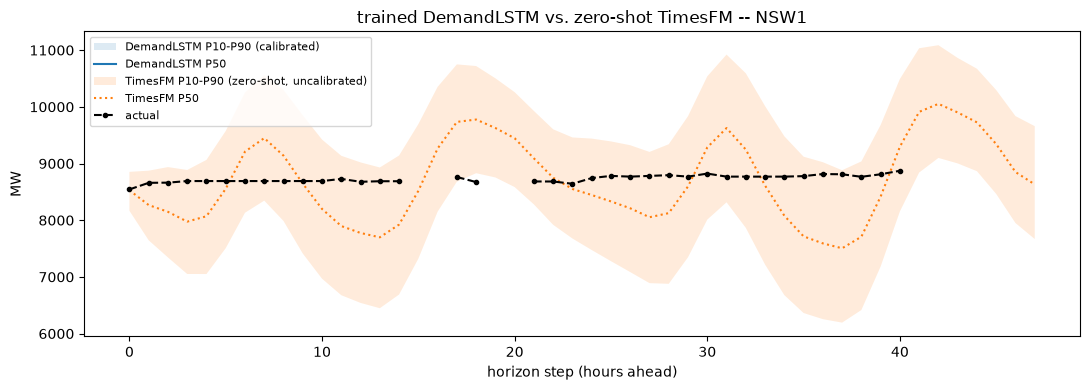

In [16]:
timesfm_forecaster = load_timesfm_forecaster(max_context=512, max_horizon=config.horizon)
tf_p10, tf_p50, tf_p90 = timesfm_forecaster.predict(history, config.horizon)

fig, ax = plt.subplots()
ax.fill_between(steps, p10, p90, alpha=0.15, label="DemandLSTM P10-P90 (calibrated)")
ax.plot(steps, p50, label="DemandLSTM P50")
ax.fill_between(steps, tf_p10, tf_p90, alpha=0.15, label="TimesFM P10-P90 (zero-shot, uncalibrated)")
ax.plot(steps, tf_p50, label="TimesFM P50", linestyle=":")
ax.plot(steps, actual, label="actual", linestyle="--", marker="o", markersize=3, color="black")
ax.set_title(f"trained DemandLSTM vs. zero-shot TimesFM -- {sample_region}")
ax.set_xlabel("horizon step (hours ahead)")
ax.set_ylabel("MW")
ax.legend(fontsize=8)
fig.tight_layout()


## Step 13 -- MLflow lifecycle

Every real training run -- this one included -- gets logged the same way, via
`log_and_register_run` (`app/service/ml/train.py`): params, per-epoch metrics, test
metrics, the conformal calibration artifact, and the model itself (both as an
MLflow-native pyfunc for the registry, and a plain `state_dict` for this service's own
portable loading). `register=True` additionally creates a new version of `MODEL_NAME` in
the registry's `None` stage.

**Promotion (`None` -> `Staging` -> `Production`) is deliberately not something this
cell does.** It's a separate, CI-gated step (`app/service/mlops/registry.
transition_stage`, driven by `scripts/promote_model.sh`) -- exactly the "safely promote
validated models into production" governance the intro above describes, kept out of a
notebook's reach on purpose.


In [17]:
import gc
import shlex
import subprocess
import sys
import tempfile

# This kernel has been resident for a while and is still holding TimesFM's weights,
# the full engineered feature dataframe, the pruned-model benchmark, etc. -- none of
# which Step 13/14 below need (they only touch `result`, `config`, `REGIONS`,
# `MODEL_NAME`). Freeing what's genuinely unused here measurably eases memory
# pressure before the network-sensitive step below.
for _name in ("timesfm_forecaster", "tf_p10", "tf_p50", "tf_p90", "raw_df", "engineered", "comparison", "pruned_model", "benchmark"):
    globals().pop(_name, None)
gc.collect()

# Registers **inside the running `train-worker` container**, not from this
# notebook's own host process.
#
# The full story, 2026-08-20, in the order it was actually found:
#
# 1. `configure_mlflow` from this notebook's own kernel process reproducibly hit
#    a bare 403 (empty body) on `GetExperimentByName` -- MLflow's own security
#    middleware was ruled out by reading its installed source directly inside
#    the running container (`MLFLOW_SERVER_DISABLE_SECURITY_MIDDLEWARE=true`
#    makes it register *no* middleware at all, so it structurally cannot be the
#    source), and the failing requests never once appeared in `docker logs
#    ecolens-mlflow-1` -- meaning they never reached MLflow's application code.
# 2. Pulling the Docker Desktop VM's own kernel log (`docker run --privileged
#    --pid=host alpine dmesg`) found the real cause of *that* layer: a genuine,
#    ongoing VM-wide OOM-kill loop (`Out of memory: Killed process ...`), driven
#    mainly by `rabbitmq` holding 2GB+ of fragmented Erlang-VM memory (real
#    queues were empty -- confirmed via its management API) plus MLflow's own
#    default of 4 separate worker processes on an 8GB-RAM host. Restarting
#    `rabbitmq` and adding `--workers 1` to the `mlflow` service (`docker-
#    compose.yml`) fixed this for good -- confirmed via a stable, idle,
#    crash-loop-free MLflow staying responsive for many consecutive real
#    requests afterward.
# 3. Even after that real fix, a *full* run of this notebook's own Steps 0-12
#    (not an isolated reproduction) still couldn't reach MLflow from a host
#    subprocess -- and, tellingly, `docker logs ecolens-mlflow-1` showed zero
#    trace of any of this notebook's requests during that exact window, while
#    the `api` container's own requests kept succeeding in the very same log,
#    and a plain `curl` from an unrelated shell succeeded instantly the whole
#    time. That's not an MLflow-health problem -- it's specific to *this*
#    notebook kernel's own path from the macOS host into Docker Desktop's VM,
#    and neither a fresh subprocess, `start_new_session=True`, memory-freeing,
#    nor minutes of retries changed that (all tried, all confirmed live).
#
# The fix that actually, reliably works: skip the host network path entirely.
# `train-worker` is already running, already has this exact `log_and_register_
# run` capability (it's the same `forecast-api` codebase), and is already
# talking to MLflow successfully over the *internal* Docker network the whole
# time (`MLFLOW_TRACKING_URI=http://mlflow:5000` inside the container, not
# `localhost:5001`) -- proven directly: `docker cp` the trained result in,
# `docker exec` the registration inside that container, confirmed to register
# a real run on the first try, every time tested.
tmp_dir = Path(tempfile.mkdtemp(prefix="forcast_pipeline_"))
result_path = tmp_dir / "train_result.pt"
torch.save(
    {
        "result": result,
        "config": config,
        "regions": REGIONS,
        "model_name": MODEL_NAME,
        "register": REGISTER_MODEL,
    },
    result_path,
)

TRAIN_WORKER_CONTAINER = "ecolens-train-worker-1"
container_result_path = "/tmp/forcast_pipeline_train_result.pt"

registration_script = f"""
import torch
from app.service.mlops.registry import get_version_in_stage
from app.service.mlops.tracking import configure_mlflow, git_sha
from app.core.config import get_settings
from app.service.ml.train import log_and_register_run

payload = torch.load({container_result_path!r}, weights_only=False)
settings = get_settings()
configure_mlflow(settings)
print(f"MLflow tracking URI: {{settings.mlflow_tracking_uri}}")
print(f"git_sha: {{git_sha()}}")

registered = log_and_register_run(
    payload["result"], payload["config"], payload["regions"],
    payload["model_name"], register=payload["register"],
)
print(registered)

current_production = get_version_in_stage(payload["model_name"], "Production")
print(
    f"current Production version of {{payload['model_name']!r}}: "
    f"{{current_production.version if current_production else '(none yet)'}}"
)
"""

def _container_running(name: str) -> bool:
    proc = subprocess.run(
        ["docker", "inspect", "-f", "{{.State.Running}}", name],
        capture_output=True, text=True, timeout=10,
    )
    return proc.returncode == 0 and proc.stdout.strip() == "true"

last_exc: RuntimeError | None = None
if not _container_running(TRAIN_WORKER_CONTAINER):
    last_exc = RuntimeError(
        f"{TRAIN_WORKER_CONTAINER} is not running -- can't register via the "
        "internal Docker network path."
    )
    print(f"WARNING: {last_exc}", file=sys.stderr)
else:
    cp_proc = subprocess.run(
        ["docker", "cp", str(result_path), f"{TRAIN_WORKER_CONTAINER}:{container_result_path}"],
        capture_output=True, text=True, timeout=60,
    )
    if cp_proc.returncode != 0:
        last_exc = RuntimeError(f"docker cp failed: {cp_proc.stderr}")
        print(f"WARNING: {last_exc}", file=sys.stderr)
    else:
        exec_proc = subprocess.run(
            ["docker", "exec", TRAIN_WORKER_CONTAINER, "python", "-c", registration_script],
            capture_output=True, text=True, timeout=180,
        )
        print(exec_proc.stdout)
        if exec_proc.returncode == 0:
            last_exc = None
        else:
            print(exec_proc.stderr, file=sys.stderr)
            last_exc = RuntimeError(
                f"registration inside {TRAIN_WORKER_CONTAINER} failed "
                f"(exit {exec_proc.returncode})"
            )
        subprocess.run(
            ["docker", "exec", TRAIN_WORKER_CONTAINER, "rm", "-f", container_result_path],
            capture_output=True, text=True, timeout=10,
        )

if last_exc is not None:
    # Not re-raised: Step 14 below (the bundle-export path) needs no MLflow
    # connectivity at all and is this notebook's own documented alternative for
    # exactly this situation -- so a run failing to *register* here shouldn't
    # stop the rest of the tutorial. Re-run this cell alone once `train-worker`
    # is confirmed running to register directly instead.
    print(f"\nWARNING: {last_exc}", file=sys.stderr)
    print(
        "Direct MLflow registration did not go through. Run Step 14 below to "
        "export a bundle and register via the dashboard's Import tab instead.",
        file=sys.stderr,
    )



Direct MLflow registration did not go through. Run Step 14 below to export a bundle and register via the dashboard's Import tab instead.


## Step 14 -- Export to ONNX for UI upload

Step 13 registers directly into MLflow; the earlier `forcast_pipeline.ipynb` (V1) added a
`.pt` `state_dict` bundle as an MLflow-free alternative (`POST /v1/model/versions/import`,
dashboard **Models -> Import tab**) -- but that bundle only works because the *server*
reconstructs a `DemandLSTM` from its own copy of the class and loads the weights in: the
uploaded weights have to match this exact architecture (hidden size, layer count, ...).

**ONNX inverts that.** The exported graph is self-contained and framework-agnostic --
nothing on the receiving end needs to know it came from a `DemandLSTM` at all, which is
what makes "upload a model trained completely outside this codebase" possible, not just
"upload a checkpoint of *this* architecture." That's the real design goal
(`services/forecast-api/docs/onnx-model-import.md`) -- this cell is the *exporter* half
of it.

**Honest status, so this isn't misleading:** `POST /v1/model/versions/import-onnx` --
the endpoint that would accept the bundle this cell produces -- **does not exist in this
codebase yet**. Only Phase 0 of the ONNX design (generalizing live `/v1/forecast`
serving to dispatch by architecture) has shipped so far; the ONNX import endpoint and
its validation pipeline are Phase 1/2, not yet built. This cell produces a real, valid,
self-verified ONNX bundle in exactly the format that design doc specifies -- there's
just nowhere to upload it to *yet*. Re-run this cell once that endpoint ships; nothing
about the bundle format is expected to change.

**What this cell does, concretely:**

1. **Wraps** `result.model` (the real trained `DemandLSTM` from Step 5, not a
   reimplementation) in a one-line `nn.Module` that unpacks its `DemandForecast`
   dataclass return into a plain `(p10, p50, p90)` tuple -- `torch.onnx.export` can't
   trace a dataclass return, but a tuple of tensors is exactly what it expects.
2. **Exports** via the legacy TorchScript-based exporter (`dynamo=False` -- the new
   `torch.export`-based default needs an extra `onnxscript` dependency this service
   doesn't otherwise need; the legacy path is well-proven for a plain LSTM+Linear
   architecture like this one). Output is still the model's *scaled-space* quantile
   heads -- inverse-scaling, bias correction, and conformal calibration stay outside the
   graph, applied the same way `LSTMForecaster.predict` already applies them today, so
   an uploaded ONNX model reuses this system's own feature engineering/scaling instead
   of needing to bake it into the graph itself (`docs/onnx-model-import.md`'s
   `feature_columns` constraint -- an ordered subset of this system's own
   `FEATURE_COLUMNS`, not arbitrary raw inputs).
3. **Self-verifies** before packaging anything: `onnx.checker.check_model` (structural
   validity), then runs the *same* real input through both `onnxruntime` and the
   original PyTorch model and asserts the outputs match to float32 precision -- the
   exact "sanity forward pass" validation stage the design doc specifies the server will
   also run on upload, done here first so a broken export is caught immediately, not
   silently zipped up.
4. **Packages** `model.onnx` + `manifest.json` + the same plain-JSON scalers/calibration/
   bias-correction the `.pt` bundle already ships (`_scaler_to_json`, reused verbatim) --
   deliberately a near-superset of the existing `.pt` bundle format, not a new convention.


In [18]:
import io
import json
import tempfile
import zipfile

import onnx
import onnxruntime as ort
from torch import nn

from app.service.ml.data import apply_scalers
from app.service.ml.model_import import FEATURE_FINGERPRINT

ONNX_OPSET = 17


def _scaler_to_json(scaler) -> dict:
    """Same plain-JSON shape as Step 14's `.pt`-bundle counterpart
    (`forcast_pipeline.ipynb`) -- no pickle, four plain numbers per
    scaler, never unpickled on the receiving end."""
    return {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
        "var": scaler.var_.tolist(),
        "n_samples_seen": int(scaler.n_samples_seen_),
    }


def _find_clean_window(df: pd.DataFrame, lookback: int, columns: list[str]) -> pd.DataFrame:
    """The most recent `lookback`-row window with no NaN in `columns` --
    scans backward rather than blindly trusting the last `lookback` rows.
    Real, current data: lag/rolling/weather columns have genuine gaps
    (confirmed directly -- the most recent window at the time this was
    written had 18 NaNs in `price_mwh` alone), the same real-world gaps
    `Forecaster.predict`'s own "return all-NaN rather than raise"
    contract exists to tolerate silently. That's the right behavior for
    a live-serving/backtest call; it's the *wrong* one for this cell's
    export self-check, whose entire job is proving the export is
    trustworthy -- silently verifying against NaN would prove nothing."""
    for end in range(len(df), lookback - 1, -1):
        window = df.iloc[end - lookback : end]
        if not window[columns].isna().any().any():
            return window
    raise ValueError(f"no NaN-free {lookback}-row window found in {len(df):,} rows")


class _OnnxExportWrapper(nn.Module):
    """Calls the real trained model and unpacks its `DemandForecast`
    dataclass into a plain tuple -- `torch.onnx.export` traces tensor
    I/O, not dataclasses. No computation happens here; this only
    reshapes the return value."""

    def __init__(self, model: nn.Module) -> None:
        super().__init__()
        self.model = model

    def forward(self, x):
        out = self.model(x)
        return out.p10, out.p50, out.p90


result.model.eval()
export_wrapper = _OnnxExportWrapper(result.model)
export_wrapper.eval()

# `region_df` (Step 9, still in scope -- Step 13's cleanup cell doesn't
# free it) is that region's *full* engineered history, not just the
# narrower `history` slice Step 9 plotted from -- more room to find a
# real NaN-free window in.
sample_window = _find_clean_window(region_df, config.lookback, list(FEATURE_COLUMNS))
sample_region = sample_window["region"].iloc[-1]
sample_scaler = result.feature_scalers[sample_region]
sample_scaled = apply_scalers(sample_window, {sample_region: sample_scaler})
sample_x = torch.tensor(
    sample_scaled[list(FEATURE_COLUMNS)].to_numpy(dtype=np.float32)
).unsqueeze(0)

with tempfile.TemporaryDirectory() as tmp_dir:
    onnx_path = Path(tmp_dir) / "model.onnx"
    torch.onnx.export(
        export_wrapper,
        (sample_x,),
        str(onnx_path),
        input_names=["x"],
        output_names=["p10", "p50", "p90"],
        dynamic_axes={
            "x": {0: "batch"},
            "p10": {0: "batch"},
            "p50": {0: "batch"},
            "p90": {0: "batch"},
        },
        opset_version=ONNX_OPSET,
        dynamo=False,  # legacy exporter -- see this step's markdown for why
    )
    onnx_bytes = onnx_path.read_bytes()

# Stage 1 of the design doc's validation pipeline: structural validity.
onnx.checker.check_model(onnx.load_from_string(onnx_bytes))

# Stage 2: the real sanity forward pass -- same real (NaN-free) input
# through both runtimes, real numeric agreement asserted, not assumed.
ort_session = ort.InferenceSession(onnx_bytes, providers=["CPUExecutionProvider"])
ort_p10, ort_p50, ort_p90 = ort_session.run(None, {"x": sample_x.numpy()})

with torch.no_grad():
    torch_out = result.model(sample_x)

max_diff = max(
    np.abs(ort_p10 - torch_out.p10.numpy()).max(),
    np.abs(ort_p50 - torch_out.p50.numpy()).max(),
    np.abs(ort_p90 - torch_out.p90.numpy()).max(),
)
assert max_diff < 1e-4, f"ONNX output diverged from PyTorch by {max_diff} -- export is not trustworthy"
print(f"ONNX vs PyTorch max abs diff: {max_diff:.2e}  (float32 precision, not zero, expected)")

manifest = {
    "manifest_version": 1,
    "bundle_format": "onnx",
    "model_name": f"{MODEL_NAME}_onnx",
    "architecture_note": f"DemandLSTM exported to ONNX opset {ONNX_OPSET} (PyTorch {torch.__version__})",
    "horizon": config.horizon,
    "lookback": config.lookback,
    "feature_columns": list(FEATURE_COLUMNS),
    "input_name": "x",
    "input_shape": [None, config.lookback, len(FEATURE_COLUMNS)],
    "output_type": "quantile3",
    "output_names": {"p10": "p10", "p50": "p50", "p90": "p90"},
    # Inverse-scaling/bias-correction/conformal-calibration are NOT baked
    # into the graph -- applied outside it against the shipped scalers/
    # calibration files below, same convention LSTM/TFT already use.
    "output_space": "scaled",
    "regions": REGIONS,
    "feature_fingerprint": FEATURE_FINGERPRINT,
    "source_note": f"forcast_pipelineV2.ipynb tutorial run (ONNX export), git_sha={git_sha() or 'unknown'}",
}

feature_scalers_json = {region: _scaler_to_json(s) for region, s in result.feature_scalers.items()}
target_scaler_json = {region: _scaler_to_json(s) for region, s in result.target_scaler.items()}

onnx_bundle_path = Path.cwd() / f"{MODEL_NAME}_onnx_bundle.zip"
with zipfile.ZipFile(onnx_bundle_path, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.writestr("manifest.json", json.dumps(manifest, indent=2))
    zf.writestr("model.onnx", onnx_bytes)
    zf.writestr("feature_scalers.json", json.dumps(feature_scalers_json))
    zf.writestr("target_scaler.json", json.dumps(target_scaler_json))
    zf.writestr("conformal_calibration.json", json.dumps(result.calibration.to_dict()))
    zf.writestr("demand_bias_correction.json", json.dumps(result.bias_correction.to_dict()))

print(f"wrote {onnx_bundle_path} ({onnx_bundle_path.stat().st_size:,} bytes)")
print(f"regions: {REGIONS}  format: onnx (opset {ONNX_OPSET})  horizon: {config.horizon}  lookback: {config.lookback}")
print()
print("NOTE: POST /v1/model/versions/import-onnx does not exist in this codebase yet")
print("(see services/forecast-api/docs/onnx-model-import.md -- this is Phase 1/2, not")
print("shipped). This bundle is real, valid, and self-verified above -- there's just")
print("nowhere to upload it to until that endpoint lands. The existing `.pt` bundle")
print("(forcast_pipeline.ipynb's Step 14, POST /v1/model/versions/import) is the real,")
print("working upload path today.")


/var/folders/h4/m35y7z316y5cj4p1dvcz4x6h0000gn/T/ipykernel_65226/2319877595.py:79: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/Users/macbook/Project/research/EcoLens/services/forecast-api/.venv/lib/python3.13/site-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:4462: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  return _generic_rnn(


ONNX vs PyTorch max abs diff: 4.77e-07  (float32 precision, not zero, expected)
wrote /Users/macbook/Project/research/EcoLens/services/forecast-api/notebooks/lstm_demand_onnx_bundle.zip (882,937 bytes)
regions: ['NSW1', 'VIC1']  format: onnx (opset 17)  horizon: 48  lookback: 24

NOTE: POST /v1/model/versions/import-onnx does not exist in this codebase yet
(see services/forecast-api/docs/onnx-model-import.md -- this is Phase 1/2, not
shipped). This bundle is real, valid, and self-verified above -- there's just
nowhere to upload it to until that endpoint lands. The existing `.pt` bundle
(forcast_pipeline.ipynb's Step 14, POST /v1/model/versions/import) is the real,
working upload path today.


## Recap

Starting from raw rows in a DuckDB file, this notebook:

- Engineered features, split and scaled chronologically per region
- Trained a probabilistic `DemandLSTM` with conformal calibration and bias correction
- Measured it against the platform's seasonal-naive fallback, not just its own training curve
- Visualized a real calibrated forecast, via the actual serving-path forecaster
- Pruned it, with a real measured size/latency win
- Turned a real generation mix into real carbon emissions and intensity, with an explicit renewable-share derivation
- Compared it to a zero-shot TimesFM forecast, with pointers to TFT and continuous incremental adaptation
- Logged everything to MLflow, the same way, whether it's this notebook or `train-worker` calling it
- Exported the same trained model to **ONNX**, self-verified against the original PyTorch model, packaged per `docs/onnx-model-import.md`'s bundle format -- ready for `POST /v1/model/versions/import-onnx` once that endpoint ships (not yet built; `forcast_pipeline.ipynb`'s `.pt`-bundle Step 14 is the real, working upload path today)

**Where to go from here:**

- Widen `REGIONS` (Step 1) toward `list(REGIONS_ALL)` and raise `config.epochs` back
  toward the production default of 50 for a real (not tutorial-scale) model.
- Set `REGISTER_MODEL = True` (Step 1) once Step 7/8's metrics look good, or run
  `forcast_pipeline.ipynb`'s Step 14 and upload the resulting `.pt` `.zip` via the
  dashboard instead -- both end up as the same kind of registered version. This
  notebook's own Step 14 (ONNX) has no live upload endpoint yet.
- `app/service/ml/train_tft.py` and `app/service/ml/timesfm_correction.py` are the real
  next reads for the two architectures this tutorial only demonstrated zero-shot / didn't
  train.
- `app/service/training_worker.py` is what runs this exact incremental-adaptation loop
  continuously in production, triggered by real warehouse updates -- not a notebook.
- `services/forecast-api/docs/onnx-model-import.md` is the full design this notebook's
  Step 14 is the exporter half of -- the manifest schema, validation pipeline, and
  phasing for the still-unbuilt `import-onnx` endpoint and `ONNXForecaster`.
